# Fire2Air Darwin — Assessment 3
## 05 Visualisation, Integration, Tomorrow Smoke Outlook and Documentation
**Member:** Dieu Yen Diep

Assessment 3 upgrades:
- visualises FSI, aligned/upwind FRP and next-day PM2.5 relationships;
- consolidates model, station, cross-station and ablation results;
- integrates the three predictions into a station-specific Tomorrow Smoke Outlook;
- creates dashboard-ready decision-support output with explicit reliability rules;
- updates the evidence manifest and README for the Assessment 3 run order;
- keeps API/dashboard deployment as optional future layers unless actually implemented.

In [7]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
%pip install boto3
%pip install "botocore[crt]"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [9]:
# ============================================================
# AWS S3 CONFIGURATION
# ============================================================
import boto3
import shutil

BUCKET = "fire2air-darwin-dan5-646468992009-ap-southeast-2-an"

NTEPA_RAW = f"s3://{BUCKET}/raw/ntepa/"
FIRMS_RAW = f"s3://{BUCKET}/raw/firms/"
NTEPA_DAILY = f"s3://{BUCKET}/processed/ntepa_daily/"
FIRMS_DAILY = f"s3://{BUCKET}/processed/firms_daily/"
MODEL_READY = f"s3://{BUCKET}/processed/model_ready/"
MODEL1_DIR = f"s3://{BUCKET}/models/model1/"
MODEL2_DIR = f"s3://{BUCKET}/models/model2/"
MODEL3_DIR = f"s3://{BUCKET}/models/model3/"
MODEL1_OUTPUT = f"s3://{BUCKET}/outputs/model1/"
MODEL2_OUTPUT = f"s3://{BUCKET}/outputs/model2/"
MODEL3_OUTPUT = f"s3://{BUCKET}/outputs/model3/"
VIS_OUTPUT = f"s3://{BUCKET}/outputs/visualisation/"
DASHBOARD_DIR = f"s3://{BUCKET}/dashboard/"
DOCUMENTATION_DIR = f"s3://{BUCKET}/documentation/"
ATHENA_RESULTS = f"s3://{BUCKET}/athena-results/"

s3 = boto3.client("s3")
LOCAL_ROOT = Path("/tmp/fire2air_a3")
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

def _prefix(uri):
    return uri.replace(f"s3://{BUCKET}/", "", 1)

def download_prefix(uri, local_dir, flatten=False):
    local_dir = Path(local_dir)
    local_dir.mkdir(parents=True, exist_ok=True)
    prefix = _prefix(uri)
    paginator = s3.get_paginator("list_objects_v2")
    downloaded = []
    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith("/"):
                continue
            rel = Path(key[len(prefix):].lstrip("/"))
            dest = local_dir / (rel.name if flatten else rel)
            dest.parent.mkdir(parents=True, exist_ok=True)
            s3.download_file(BUCKET, key, str(dest))
            downloaded.append(dest)
    return downloaded

def upload_file(local_path, uri, object_name=None):
    local_path = Path(local_path)
    prefix = _prefix(uri).rstrip("/")
    key = f"{prefix}/{object_name or local_path.name}"
    s3.upload_file(str(local_path), BUCKET, key)
    print(f"Uploaded: s3://{BUCKET}/{key}")

def upload_tree(local_dir, uri):
    local_dir = Path(local_dir)
    if not local_dir.exists():
        return
    prefix = _prefix(uri).rstrip("/")
    for p in local_dir.rglob("*"):
        if p.is_file():
            rel = p.relative_to(local_dir).as_posix()
            key = f"{prefix}/{rel}"
            s3.upload_file(str(p), BUCKET, key)
    print(f"Uploaded folder: {local_dir} -> {uri}")

In [10]:
project_folder = LOCAL_ROOT / "visualisation_workspace"
if project_folder.exists():
    shutil.rmtree(project_folder)
project_folder.mkdir(parents=True, exist_ok=True)

# Shared datasets from Script 01.
download_prefix(MODEL_READY, project_folder, flatten=True)
download_prefix(NTEPA_DAILY, project_folder, flatten=True)
download_prefix(FIRMS_DAILY, project_folder, flatten=True)

output_root = project_folder / "outputs_prt661_a3"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
for folder in [table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Bring model tables produced by Scripts 02-04 into the consolidation workspace.
download_prefix(MODEL1_OUTPUT + "tables/", table_dir, flatten=True)
download_prefix(MODEL2_OUTPUT + "tables/", table_dir, flatten=True)
download_prefix(MODEL3_OUTPUT + "tables/", table_dir, flatten=True)

model_table = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint_A3.csv",
    parse_dates=["date", "target_date"],
)
daily_air = pd.read_csv(
    project_folder / "Fire2Air_ntepa_daily_checkpoint_A3.csv",
    parse_dates=["date"],
)
fire_daily = pd.read_csv(
    project_folder / "Fire2Air_firms_daily_checkpoint_A3.csv",
    parse_dates=["date_darwin"],
)
with open(project_folder / "Fire2Air_feature_manifest_A3.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)
model_features = manifest["features"]
PM25_THRESHOLD = float(manifest["threshold_pm25_ug_m3"])
MAX_FIRE_DISTANCE_KM = float(manifest["max_fire_distance_km"])

print("Project folder:", project_folder)
print("Model-ready rows:", len(model_table))
print("Predictors:", len(model_features))

Project folder: \tmp\fire2air_a3\visualisation_workspace
Model-ready rows: 7530
Predictors: 93


## A. Updated Assessment 3 architecture

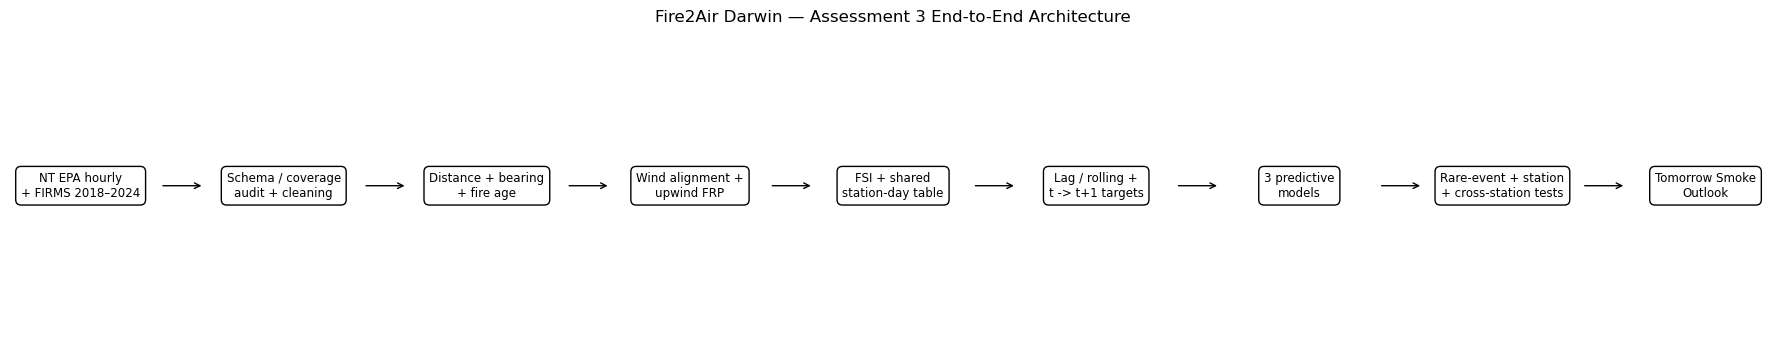

In [11]:
stages = [
    "NT EPA hourly\n+ FIRMS 2018–2024",
    "Schema / coverage\naudit + cleaning",
    "Distance + bearing\n+ fire age",
    "Wind alignment +\nupwind FRP",
    "FSI + shared\nstation-day table",
    "Lag / rolling +\nt -> t+1 targets",
    "3 predictive\nmodels",
    "Rare-event + station\n+ cross-station tests",
    "Tomorrow Smoke\nOutlook",
]
fig, ax = plt.subplots(figsize=(18, 3.5))
ax.axis("off")
xs = np.linspace(0.04, 0.96, len(stages))
for i, (x, label) in enumerate(zip(xs, stages)):
    ax.text(
        x, 0.5, label, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="black"),
        transform=ax.transAxes, fontsize=8.5,
    )
    if i < len(stages) - 1:
        ax.annotate(
            "", xy=(xs[i + 1] - 0.045, 0.5), xytext=(x + 0.045, 0.5),
            xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->"),
        )
ax.set_title("Fire2Air Darwin — Assessment 3 End-to-End Architecture", pad=14)
fig.tight_layout()
fig.savefig(figure_dir / "a3_01_updated_architecture.png", dpi=180, bbox_inches="tight")
plt.show()

## B. Core EDA: PM2.5 trend, station distribution and exceedance frequency

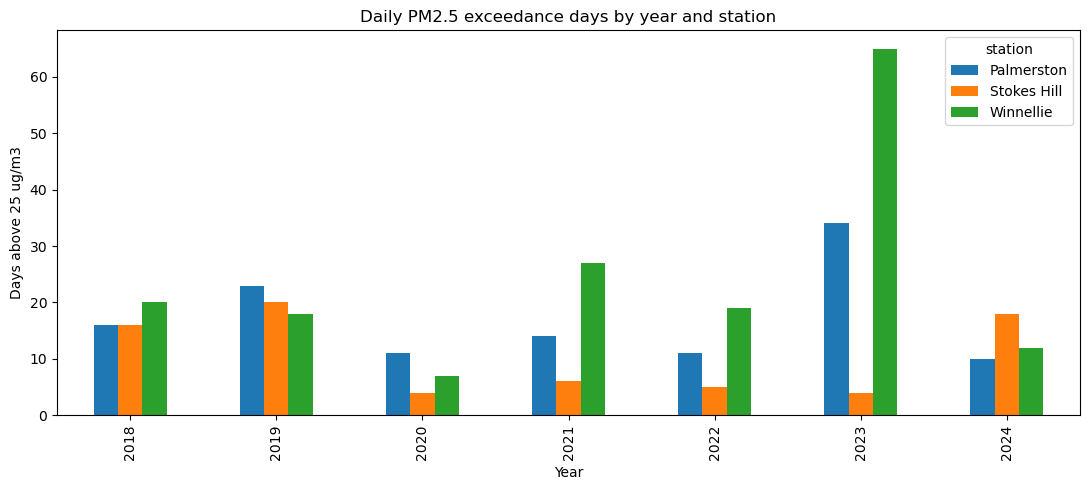

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
for station, g in daily_air.sort_values("date").groupby("station"):
    smoothed = g.set_index("date")["pm25_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smoothed.index, smoothed.values, label=station, linewidth=1)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1, label="25 ug/m3")
ax.set_title("30-day rolling daily mean PM2.5 by station")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "a3_02_pm25_trend_by_station.png", dpi=180, bbox_inches="tight")
plt.close(fig)

stations = sorted(daily_air["station"].dropna().unique())
data = [daily_air.loc[daily_air["station"].eq(s), "pm25_mean"].dropna() for s in stations]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=stations, showfliers=False)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Daily mean PM2.5 distribution by station")
ax.set_ylabel("PM2.5 (ug/m3)")
fig.tight_layout()
fig.savefig(figure_dir / "a3_03_pm25_distribution_by_station.png", dpi=180, bbox_inches="tight")
plt.close(fig)

exceedance_counts = (
    daily_air.dropna(subset=["pm25_mean"])
    .assign(year=lambda d: d["date"].dt.year, exceedance=lambda d: (d["pm25_mean"] > PM25_THRESHOLD).astype(int))
    .groupby(["year", "station"])["exceedance"].sum()
    .unstack("station").fillna(0)
)
ax = exceedance_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Daily PM2.5 exceedance days by year and station")
ax.set_xlabel("Year")
ax.set_ylabel("Days above 25 ug/m3")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(figure_dir / "a3_04_exceedance_days_by_year_station.png", dpi=180, bbox_inches="tight")
plt.show()